In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA


In [2]:
df = pd.read_csv("../data/processed/japan_feature_engineered.csv")

df.head()


,Year,Total_Population,Elderly_Percent,GDP,Fertility_Rate,Elderly_Population,Working_Age_Population,Dependency_Ratio,GDP_Per_Capita,Population_Growth_Rate,Elderly_scaled,Dependency_scaled,PopGrowth_scaled,Demographic_Risk_Score
0,1990,123478000.0,12.159237,3.185905e+12,1.54,1.501398e+07,1.084640e+08,0.138424,25801.395039,NaN,0.000000,0.000000,NaN,NaN
1,1991,123964000.0,12.642663,3.648066e+12,1.53,1.567235e+07,1.082916e+08,0.144724,29428.428904,0.003936,0.027434,0.022052,1.000000,1.979421
2,1992,124425000.0,13.146100,3.980703e+12,1.50,1.635703e+07,1.080680e+08,0.151359,31992.790212,0.003719,0.056003,0.045277,0.975323,4.544757
3,1993,124829000.0,13.645147,4.536940e+12,1.46,1.703310e+07,1.077959e+08,0.158013,36345.244126,0.003247,0.084324,0.068567,0.921686,7.681918
4,1994,125178000.0,14.147171,4.998798e+12,1.50,1.770915e+07,1.074689e+08,0.164784,39933.515056,0.002796,0.112813,0.092270,0.870411,10.795092


In [3]:
population_series = df.set_index("Year")["Total_Population"]

population_series.head()


Year
1990    123478000.0
1991    123964000.0
1992    124425000.0
1993    124829000.0
1994    125178000.0
Name: Total_Population, dtype: float64

In [4]:
model = ARIMA(population_series, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:       Total_Population   No. Observations:                   35
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -526.973
Date:                Mon, 16 Feb 2026   AIC                           1059.946
Time:                        12:02:51   BIC                           1064.525
Sample:                             0   HQIC                          1061.507
                                 - 35                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8597      0.017     50.227      0.000       0.826       0.893
ma.L1         -0.8550      0.017    -48.923      0.000      -0.889      -0.821
sigma2      8.921e+09   1.01e-12   8.86e+21      0.0

c:\projects\japan_crisis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\projects\japan_crisis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\projects\japan_crisis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [5]:
forecast_steps = 26

forecast = model_fit.forecast(steps=forecast_steps)

forecast


c:\projects\japan_crisis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\projects\japan_crisis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


35    1.239675e+08
36    1.239607e+08
37    1.239549e+08
38    1.239499e+08
39    1.239456e+08
40    1.239419e+08
41    1.239387e+08
42    1.239360e+08
43    1.239336e+08
44    1.239316e+08
45    1.239299e+08
46    1.239284e+08
47    1.239271e+08
48    1.239260e+08
49    1.239250e+08
50    1.239242e+08
51    1.239235e+08
52    1.239229e+08
53    1.239224e+08
54    1.239219e+08
55    1.239216e+08
56    1.239212e+08
57    1.239209e+08
58    1.239207e+08
59    1.239205e+08
60    1.239203e+08
Name: predicted_mean, dtype: float64

In [6]:
last_year = df["Year"].max()

future_years = [last_year + i for i in range(1, forecast_steps + 1)]

forecast_df = pd.DataFrame({
    "Year": future_years,
    "Forecast_Population": forecast.values
})

forecast_df.head()


,Year,Forecast_Population
0,2025,1.239675e+08
1,2026,1.239607e+08
2,2027,1.239549e+08
3,2028,1.239499e+08
4,2029,1.239456e+08


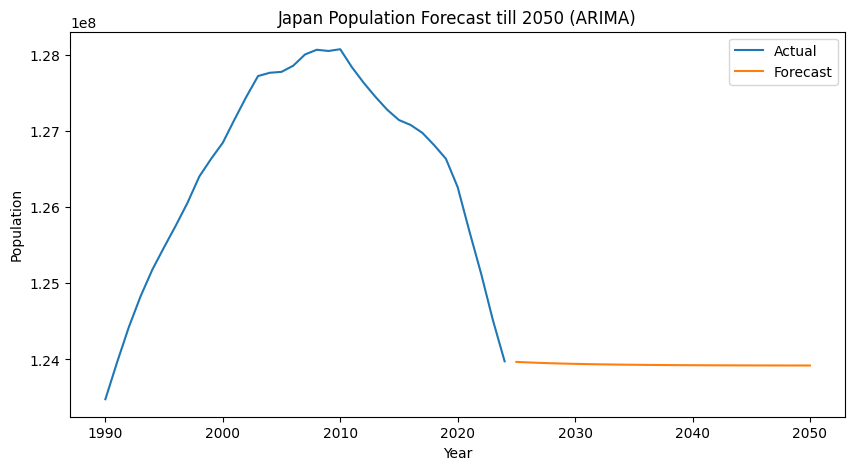

In [7]:
plt.figure(figsize=(10,5))

# Actual
plt.plot(df["Year"], df["Total_Population"], label="Actual")

# Forecast
plt.plot(forecast_df["Year"], forecast_df["Forecast_Population"], label="Forecast")

plt.legend()
plt.title("Japan Population Forecast till 2050 (ARIMA)")
plt.xlabel("Year")
plt.ylabel("Population")
plt.show()


In [8]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(population_series)

print("ADF Statistic:", result[0])
print("p-value:", result[1])


ADF Statistic: -0.3794197949310425
p-value: 0.9134786428567258


In [9]:
import pmdarima as pm

auto_model = pm.auto_arima(
    population_series,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True
)

print(auto_model.summary())



                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   35
Model:               SARIMAX(1, 0, 3)   Log Likelihood                -475.773
Date:                Mon, 16 Feb 2026   AIC                            961.546
Time:                        12:07:20   BIC                            969.323
Sample:                             0   HQIC                           964.231
                                 - 35                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.002    466.334      0.000       0.996       1.004
ma.L1          1.1631      0.872      1.334      0.182      -0.545       2.871
ma.L2          0.9051      1.053      0.859      0.3

In [10]:
model = ARIMA(population_series, order=auto_model.order)
model_fit = model.fit()


c:\projects\japan_crisis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\projects\japan_crisis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\projects\japan_crisis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\projects\japan_crisis\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autor

c:\projects\japan_crisis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\projects\japan_crisis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


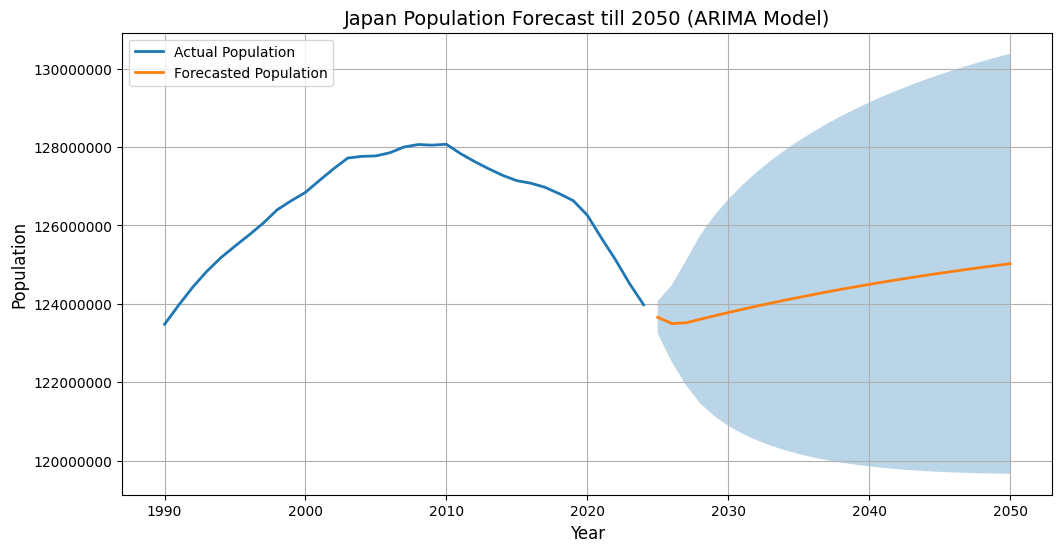

In [11]:
# Get forecast with confidence intervals
forecast_result = model_fit.get_forecast(steps=26)

forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

# Create future years
last_year = df["Year"].max()
future_years = [last_year + i for i in range(1, 27)]

# Plot
plt.figure(figsize=(12,6))

# Actual Population
plt.plot(
    df["Year"],
    df["Total_Population"],
    label="Actual Population",
    linewidth=2
)

# Forecasted Population
plt.plot(
    future_years,
    forecast_mean,
    label="Forecasted Population",
    linewidth=2
)

# Confidence Interval
plt.fill_between(
    future_years,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    alpha=0.3
)

plt.title("Japan Population Forecast till 2050 (ARIMA Model)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Population", fontsize=12)

plt.ticklabel_format(style='plain', axis='y')  # Remove scientific notation
plt.legend()
plt.grid(True)

plt.show()
